In [1]:
import gensim, nltk, re, urllib, os
from lxml import etree
from nltk.tokenize import word_tokenize, sent_tokenize

print(f"gensim version: {gensim.__version__}")
nltk.download('punkt')

gensim version: 4.4.0


[nltk_data] Downloading package punkt to /home/affx/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 1. 영어 Word2Vec
- gensim 패키지는 자연어 처리 작업을 도와주는 오픈소스 라이브러리로, Word2Vec을 지원

### 1.1 훈련 데이터 다운로드 및 전처리
- 훈련 데이터 파일은 xml 문법으로 작성되어 있음
- `<content>`부터 `</content>` 사이의 내용 중 배경음 지문 등을 제거하여 전처리

In [2]:
# 데이터 다운로드
urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/09.%20Word%20Embedding/dataset/ted_en-20160408.xml", filename="data/ted_en-20160408.xml")

('data/ted_en-20160408.xml', <http.client.HTTPMessage at 0x72fd95b57e30>)

In [3]:
targetXML = open('data/ted_en-20160408.xml', 'r', encoding='UTF8')
print(targetXML.read(30000))  # 앞에서 30000글자만 읽기
targetXML.seek(0)  # 다시 처음부터 읽을 수 있도록 파일 포인터 위치를 변경

target_text = etree.parse(targetXML)

# xml 파일로부터 <content>와 </content> 사이의 내용만 가져온다.
parse_text = '\n'.join(target_text.xpath('//content/text()'))

# 정규 표현식의 sub 모듈을 통해 content 중간에 등장하는 (Audio), (Laughter) 등의 배경음 부분을 제거.
# 해당 코드는 괄호로 구성된 내용을 제거.
content_text = re.sub(r'\([^)]*\)', '', parse_text)

# 입력 코퍼스에 대해서 NLTK를 이용하여 문장 토큰화를 수행.
sent_text = sent_tokenize(content_text)

# 각 문장에 대해서 구두점을 제거하고, 대문자를 소문자로 변환.
normalized_text = []
for string in sent_text:
     tokens = re.sub(r"[^a-z0-9]+", " ", string.lower())
     normalized_text.append(tokens)

# 각 문장에 대해서 NLTK를 이용하여 단어 토큰화를 수행.
result = [word_tokenize(sentence) for sentence in normalized_text]

<?xml version="1.0" encoding="UTF-8"?>
<xml language="en"><file id="1">
  <head>
    <url>http://www.ted.com/talks/knut_haanaes_two_reasons_companies_fail_and_how_to_avoid_them</url>
    <pagesize>72832</pagesize>
    <dtime>Fri Apr 01 00:57:03 CEST 2016</dtime>
    <encoding>UTF-8</encoding>
    <content-type>text/html; charset=utf-8</content-type>
    <keywords>talks, business, creativity, curiosity, goal-setting, innovation, motivation, potential, success, work</keywords>
    <speaker>Knut Haanaes</speaker>
    <talkid>2470</talkid>
    <videourl>http://download.ted.com/talks/KnutHaanaes_2015S.mp4</videourl>
    <videopath>talks/KnutHaanaes_2015S.mp4</videopath>
    <date>2015/06/30</date>
    <title>Knut Haanaes: Two reasons companies fail -- and how to avoid them</title>
    <description>TED Talk Subtitles and Transcript: Is it possible to run a company and reinvent it at the same time? For business strategist Knut Haanaes, the ability to innovate after becoming successful is the 

In [4]:
print('총 샘플의 개수 : {}'.format(len(result)))

총 샘플의 개수 : 273424


### 1.2 Word2Vec 훈련

In [5]:
# 샘플 3개만 출력
for line in result[:3]:
    print(line)

['here', 'are', 'two', 'reasons', 'companies', 'fail', 'they', 'only', 'do', 'more', 'of', 'the', 'same', 'or', 'they', 'only', 'do', 'what', 's', 'new']
['to', 'me', 'the', 'real', 'real', 'solution', 'to', 'quality', 'growth', 'is', 'figuring', 'out', 'the', 'balance', 'between', 'two', 'activities', 'exploration', 'and', 'exploitation']
['both', 'are', 'necessary', 'but', 'it', 'can', 'be', 'too', 'much', 'of', 'a', 'good', 'thing']


In [6]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

In [7]:
model = Word2Vec(sentences=result, vector_size=100, window=5, min_count=5, workers=os.cpu_count()-1, sg=0)

여기서 Word2Vec의 인자는 다음과 같습니다.  

* size = 워드 벡터의 특징 값. 즉, 임베딩 된 벡터의 차원.
* window = 컨텍스트 윈도우 크기
* min_count = 단어 최소 빈도 수 제한 (빈도가 적은 단어들은 학습하지 않는다.)
* workers = 학습을 위한 프로세스 수
* sg = 0은 CBOW, 1은 Skip-gram.

In [8]:
model_result = model.wv.most_similar("man")
print(model_result)

[('woman', 0.8644798994064331), ('guy', 0.8174723386764526), ('lady', 0.7983263731002808), ('girl', 0.7758843302726746), ('boy', 0.7724864482879639), ('gentleman', 0.7380803823471069), ('soldier', 0.7167999744415283), ('kid', 0.6998113989830017), ('poet', 0.6641768217086792), ('physicist', 0.6580298542976379)]


### 1.3 모델 저장 및 로드

In [9]:
model.wv.save_word2vec_format('models/eng_w2v_1204') # 모델 저장
loaded_model = KeyedVectors.load_word2vec_format("models/eng_w2v_1204") # 모델 로드

In [10]:
model_result = loaded_model.most_similar("man")
print(model_result)

[('woman', 0.8644798994064331), ('guy', 0.8174723386764526), ('lady', 0.7983263731002808), ('girl', 0.7758843302726746), ('boy', 0.7724864482879639), ('gentleman', 0.7380803823471069), ('soldier', 0.7167999744415283), ('kid', 0.6998113989830017), ('poet', 0.6641768217086792), ('physicist', 0.6580298542976379)]


# 2. 한국어 Word2Vec

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from tqdm import tqdm
from gensim.models.word2vec import Word2Vec
from konlpy.tag import Okt

### 2.1 데이터 다운로드 및 전처리

In [12]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt", filename="data/ratings.txt")

('data/ratings.txt', <http.client.HTTPMessage at 0x72fd71dc9c10>)

In [13]:
train_data = pd.read_table('data/ratings.txt')

In [14]:
train_data[:5] # 상위 5개 출력

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1


In [15]:
print('리뷰 개수 :',len(train_data))

리뷰 개수 : 200000


In [16]:
print(f'NULL 값 개수 : {train_data.isnull().sum().sum()}')

NULL 값 개수 : 8


In [17]:
train_data = train_data.dropna(how = 'any') # Null 값이 존재하는 행 제거
print(f'NULL 값 개수 : {train_data.isnull().sum().sum()}') # Null 값이 존재하는지 확인

NULL 값 개수 : 0


In [18]:
print('리뷰 개수 :',len(train_data))

리뷰 개수 : 199992


In [19]:
# 정규 표현식을 통한 한글 외 문자 제거
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)

In [20]:
train_data[:5] # 상위 5개 출력

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,디자인을 배우는 학생으로 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업...,1
2,4655635,폴리스스토리 시리즈는 부터 뉴까지 버릴께 하나도 없음 최고,1
3,9251303,와 연기가 진짜 개쩔구나 지루할거라고 생각했는데 몰입해서 봤다 그래 이런게 진짜 영화지,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화,1


### 2.2 데이터 토큰화

In [21]:
# 불용어 정의
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

In [22]:
# 형태소 분석기 OKT를 사용한 토큰화 작업 (다소 시간 소요)
okt = Okt()

tokenized_data = []
for sentence in tqdm(train_data['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    tokenized_data.append(stopwords_removed_sentence)

100%|██████████| 199992/199992 [06:47<00:00, 490.93it/s] 


In [23]:
print(tokenized_data[:3])

[['어리다', '때', '보고', '지금', '다시', '보다', '재밌다', 'ㅋㅋ'], ['디자인', '을', '배우다', '학생', '외국', '디자이너', '그', '일군', '전통', '을', '통해', '발전', '문화', '산업', '부럽다', '사실', '우리나라', '에서도', '그', '어렵다', '시절', '끝', '까지', '열정', '을', '지키다', '노라노', '같다', '전통', '있다', '저', '같다', '사람', '꿈', '을', '꾸다', '이루다', '나가다', '수', '있다', '것', '감사하다'], ['폴리스스토리', '시리즈', '부터', '뉴', '까지', '버리다', '하나', '없다', '최고']]


리뷰의 최대 길이 : 72
리뷰의 평균 길이 : 10.716703668146726
리뷰의 전체 개수 : 199992


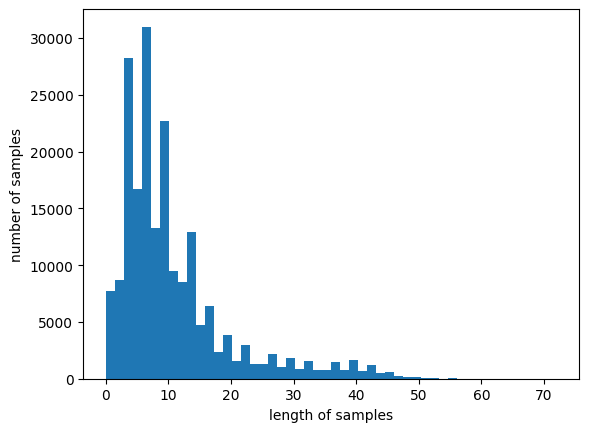

In [24]:
# 리뷰 길이 분포 확인
print('리뷰의 최대 길이 :',max(len(l) for l in tokenized_data))
print('리뷰의 평균 길이 :',sum(map(len, tokenized_data))/len(tokenized_data))
print('리뷰의 전체 개수 :',len(tokenized_data))
plt.hist([len(s) for s in tokenized_data], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

### 2.3 Word2Vec 훈련

In [25]:
from gensim.models import Word2Vec

In [26]:
model = Word2Vec(sentences = tokenized_data, vector_size = 100, window = 5, min_count = 5, workers = os.cpu_count()-1, sg = 0)
model.wv.save_word2vec_format('models/kor_w2v_1204') # 모델 저장
loaded_model = KeyedVectors.load_word2vec_format("models/kor_w2v_1204") # 모델 로드

In [27]:
# min_count=5 로 단어 빈도 수가 5회 미만인 단어들은 학습에서 제외됨
print('완성된 임베딩 매트릭스의 크기 확인 :', model.wv.vectors.shape)

완성된 임베딩 매트릭스의 크기 확인 : (16477, 100)


In [28]:
print(model.wv.most_similar("최민식"))

[('안성기', 0.8491706252098083), ('한석규', 0.8445791006088257), ('임원희', 0.8415427803993225), ('이민호', 0.8369075655937195), ('송강호', 0.8366089463233948), ('최민수', 0.8327288031578064), ('공효진', 0.8292407393455505), ('박중훈', 0.8287839889526367), ('이정재', 0.8137581944465637), ('엄태웅', 0.8109429478645325)]


In [29]:
print(model.wv.most_similar("히어로"))

[('슬래셔', 0.8517084121704102), ('호러', 0.8478689789772034), ('무협', 0.8291776776313782), ('무비', 0.8190408945083618), ('느와르', 0.8059236407279968), ('블랙', 0.8032286167144775), ('물', 0.8025704622268677), ('물의', 0.796944260597229), ('블록버스터', 0.7919492721557617), ('로코', 0.7896867990493774)]


In [30]:
print(model.wv.most_similar("발연기"))

[('어색', 0.7590680718421936), ('연기', 0.7561966180801392), ('발음', 0.746486485004425), ('연기력', 0.7242890000343323), ('사투리', 0.723851203918457), ('조연', 0.7021725177764893), ('캐스팅', 0.701690137386322), ('명연기', 0.6917691230773926), ('조진웅', 0.6625548005104065), ('류승범', 0.6599023342132568)]


# 3. 사전 훈련된 Word2Vec
- 훈련 데이터의 양이 부족한 상황이라면, 다른 방대한 데이터로 학습된 임베딩 벡터들을 사용하는 것이 나을 수도 있음
- 구글은 사전 훈련된 3백만 개의 Word2Vec 단어 벡터들을 제공함

In [31]:
!gdown https://drive.google.com/uc?id=1Av37IVBQAAntSe1X3MOAl5gvowQzd2_j --output models/GoogleNews-vectors-negative300.bin.gz
word2vec_model = gensim.models.KeyedVectors.load_word2vec_format('models/GoogleNews-vectors-negative300.bin.gz', binary=True)

Downloading...
From (original): https://drive.google.com/uc?id=1Av37IVBQAAntSe1X3MOAl5gvowQzd2_j
From (redirected): https://drive.google.com/uc?id=1Av37IVBQAAntSe1X3MOAl5gvowQzd2_j&confirm=t&uuid=02242af3-bea7-46db-a9b0-1a320a7d314f
To: /home/affx/pytorch-nlp-tutorial/12. Embedding/models/GoogleNews-vectors-negative300.bin.gz
100%|██████████████████████████████████████| 1.65G/1.65G [00:53<00:00, 31.0MB/s]


In [32]:
# 임베딩 매트릭스의 크기 출력: 300만 단어의 300차원 임베딩 벡터
print(word2vec_model.vectors.shape)

(3000000, 300)


In [33]:
print(word2vec_model.similarity('this', 'is'))
print(word2vec_model.similarity('post', 'book'))

0.40797037
0.057204384


In [34]:
print(word2vec_model['book'])

[ 0.11279297 -0.02612305 -0.04492188  0.06982422  0.140625    0.03039551
 -0.04370117  0.24511719  0.08740234 -0.05053711  0.23144531 -0.07470703
  0.21875     0.03466797 -0.14550781  0.05761719  0.00671387 -0.00701904
  0.13183594 -0.25390625  0.14355469 -0.140625   -0.03564453 -0.21289062
 -0.24804688  0.04980469 -0.09082031  0.14453125  0.05712891 -0.10400391
 -0.19628906 -0.20507812 -0.27539062  0.03063965  0.20117188  0.17382812
  0.09130859 -0.10107422  0.22851562 -0.04077148  0.02709961 -0.00106049
  0.02709961  0.34179688 -0.13183594 -0.078125    0.02197266 -0.18847656
 -0.17480469 -0.05566406 -0.20898438  0.04858398 -0.07617188 -0.15625
 -0.05419922  0.01672363 -0.02722168 -0.11132812 -0.03588867 -0.18359375
  0.28710938  0.01757812  0.02185059 -0.05664062 -0.01251221  0.01708984
 -0.21777344 -0.06787109  0.04711914 -0.00668335  0.08544922 -0.02209473
  0.31835938  0.01794434 -0.02246094 -0.03051758 -0.09570312  0.24414062
  0.20507812  0.05419922  0.29101562  0.03637695  0.04

## 4. 임베딩 벡터 시각화
### 4.1 워드 임베딩 모델로부터 2개의 tsv 파일 생성하기

In [35]:
# --output_metadata.tsv와 --output_vectors.tsv 파일 생성
!python -m gensim.scripts.word2vec2tensor --input models/eng_w2v_1204 --output models/eng_w2v

2025-12-09 12:03:56,674 - word2vec2tensor - INFO - running /home/affx/pytorch-nlp-tutorial/.venv/lib/python3.12/site-packages/gensim/scripts/word2vec2tensor.py --input models/eng_w2v_1204 --output models/eng_w2v
2025-12-09 12:03:56,674 - keyedvectors - INFO - loading projection weights from models/eng_w2v_1204
2025-12-09 12:03:57,642 - utils - INFO - KeyedVectors lifecycle event {'msg': 'loaded (21613, 100) matrix of type float32 from models/eng_w2v_1204', 'binary': False, 'encoding': 'utf8', 'datetime': '2025-12-09T12:03:57.641202', 'gensim': '4.4.0', 'python': '3.12.3 (main, Nov  6 2025, 13:44:16) [GCC 13.3.0]', 'platform': 'Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39', 'event': 'load_word2vec_format'}
2025-12-09 12:03:58,500 - word2vec2tensor - INFO - 2D tensor file saved to models/eng_w2v_tensor.tsv
2025-12-09 12:03:58,500 - word2vec2tensor - INFO - Tensor metadata file saved to models/eng_w2v_metadata.tsv
2025-12-09 12:03:58,501 - word2vec2tensor - INFO - finished

### 4.2 임베딩 프로젝터를 사용하여 시각화하기
[임베딩 프로젝터](https://projector.tensorflow.org/)에 접속하여 두 .tsv 파일 업로드